HOMEWORK 2: Linear Regression with 2026 Car Fuel Efficiency dataset

In [76]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [77]:
# Dataset
df = pd.read_csv('car_fuel_efficiency_2026.csv')

In [78]:
df = df[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']]
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  10000 non-null  int64  
 1   horsepower           9123 non-null   float64
 2   vehicle_weight       10000 non-null  int64  
 3   model_year           10000 non-null  int64  
 4   fuel_efficiency_mpg  10000 non-null  float64
dtypes: float64(2), int64(3)
memory usage: 390.8 KB


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

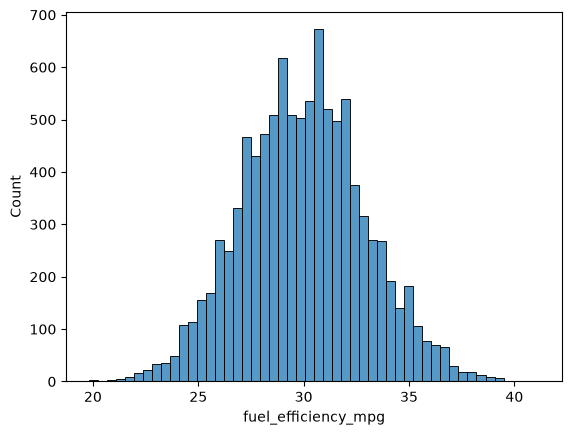

In [79]:
#EDA
sns.histplot(data=df.fuel_efficiency_mpg, bins=50)

EDA: The histogram presents a seemingly normal distribution. Since there are no long tails, it will not be necessary to apply log(x)

Q1: There is one column with missing values, which is it?

In [80]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

A1: Column 'horsepower' has 877 missing values

Q2: What is the median (50% percentile) for variable 'horsepower'?

In [81]:
df.horsepower.describe()

count    9123.000000
mean      254.446016
std        22.844613
min       171.000000
25%       239.000000
50%       254.000000
75%       270.000000
max       334.000000
Name: horsepower, dtype: float64

A2: The median of 'horsepower' is 254.0

Prepare and split the dataset

In [117]:
n = len(df)
n_val = int(n*0.2)
n_test = int(n*0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train: n_train+n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

print(len(df_train), len(df_val), len(df_test))

6000 2000 2000


In [118]:
# Reseting the index of dataframes
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [119]:
# Separating the target variable from the features
y_train = df_train.fuel_efficiency_mpg
y_val = df_val.fuel_efficiency_mpg
y_test = df_test.fuel_efficiency_mpg

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [85]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  6000 non-null   int64  
 1   horsepower           5462 non-null   float64
 2   vehicle_weight       6000 non-null   int64  
 3   model_year           6000 non-null   int64  
dtypes: float64(1), int64(3)
memory usage: 187.6 KB


Q3: Linear regression with no regularization:
(a) Replace missing numbers with 0.
(b) Replace missing numbers with the mean (of training dataset only).
- Train the model
- Evaluate the model with the validation set
- Calculate and compare RMSE scores (round RMSE scores to 3 decimal digits)

In [86]:
# Linear Regression Function
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)

    return w[0], w[1:]

In [151]:
# Data preparation function
def prepare_X(df, m):
    df = df.copy()
    df_num = df.fillna(m)
    X = df_num.values
    return X

In [88]:
# RMSE score function
def rmse(y, y_pred):
    se = (y-y_pred)**2
    mse = se.mean()
    rmse = np.sqrt(mse)
    return rmse

In [89]:
# a. Replace missing values with 0. Train the model. Calculate RMSE score on validation dataset.
X_train = prepare_X(df_train, m=0)
X_val = prepare_X(df_val, m=0)

w0_a, w_a = train_linear_regression(X_train, y_train)
y_a = w0_a + X_val.dot(w_a)
score_a = rmse(y_val, y_a)
round(score_a, 3)

np.float64(2.205)

In [90]:
np.mean(df_train.horsepower)

np.float64(254.46338337605272)

In [91]:
X_train = prepare_X(df_train, m=np.mean(df_train.horsepower))
X_val = prepare_X(df_val, m=np.mean(df_train.horsepower))

w0_b, w_b = train_linear_regression(X_train, y_train)
y_b = w0_b + X_val.dot(w_b)
score_b = rmse(y_val, y_b)
round(score_b, 3)

np.float64(2.202)

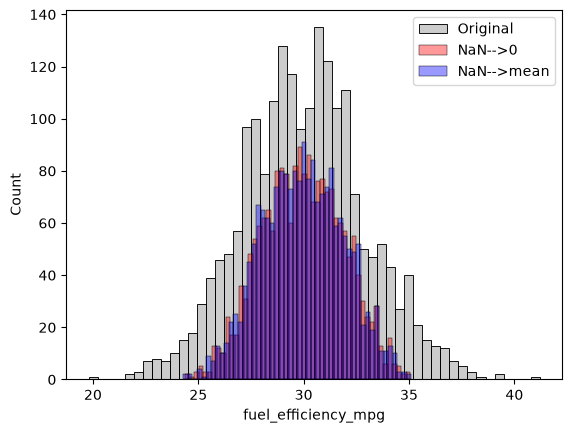

In [92]:
sns.histplot(data=y_val, color='gray', alpha=0.4, label='Original', bins=50)
sns.histplot(data=y_a, color='red', alpha=0.4, label='NaN-->0', bins=50)
sns.histplot(data=y_b, color='blue', alpha=0.4, label='NaN-->mean', bins=50)
plt.legend()

A3: Both options, replacing NaN values with 0 or the mean, are equally good (to be more precise, replacing with MEAN is slightly better)

Q4: Regularized Linear Regression training
- Fill the NAs with 0
- Try different values of r (0, 0.01, 0.1, 1, 5, 10, 100)
- Evaluate the model on the validation set, calculating RMSE

In [120]:
# Defining the training function with regularization
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.ones(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)

    return w[0], w[1:]

In [133]:
r_values = np.array([0, 0.01, 0.1, 1, 5, 10, 100])
scores = np.empty(shape=(len(r_values)))


for i, r in enumerate(r_values):
    X_train = prepare_X(df_train, m=0)
    X_val = prepare_X(df_val, m=0)

    w0, w = train_linear_regression_reg(X_train, y_train, r)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)
    scores[i] = round(score, 4)

r_scores = np.column_stack((r_values, scores))
print(r_scores)



[[0.0000e+00 2.2053e+00]
 [1.0000e-02 2.2058e+00]
 [1.0000e-01 2.2241e+00]
 [1.0000e+00 2.3491e+00]
 [5.0000e+00 2.4093e+00]
 [1.0000e+01 2.4194e+00]
 [1.0000e+02 2.4291e+00]]


A4: For this seed (42), the best regularization parameter value is 0.

Q5: Seed selection for data splitting
- Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
- For each seed do the train/validation/test split with 60%/20%/20%
- Fill missing values with 0 and train with no regularization
- For each seed, evaluate the model on the validation dataset and collect RMSE scores
- What's the standard deviation of all the scores? (use np.std)
- Round the result to 3 decimal digits (use round(std, 3))

In [140]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')
df = df[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']]

n = len(df)
n_val = int(n*0.2)
n_test = int(n*0.2)
n_train = n - n_val - n_test

seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
rmse_scores = np.zeros(len(seeds))

In [147]:
for i,s in enumerate(seeds):
    np.random.seed(s)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train+n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)
    df_test = df_val.reset_index(drop=True)

    y_train = df_train['fuel_efficiency_mpg']
    y_val = df_val['fuel_efficiency_mpg']
    y_test = df_test['fuel_efficiency_mpg']

    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    X_train = prepare_X(df_train, m=0)
    X_val = prepare_X(df_val, m=0)

    w0, w = train_linear_regression(X_train, y_train)
    y_pred = w0 + X_val.dot(w)
    rmse_scores[i] = rmse(y_val, y_pred)

std = np.std(rmse_scores)
print(rmse_scores)
print(f'Mean: {round(np.mean(rmse_scores), 3)}')
print(f'STD: {round(std, 3)}')

[2.23920414 2.20211282 2.16341978 2.20435888 2.20188009 2.24578515
 2.26972121 2.1907946  2.2166112  2.20703659]
Mean: 2.214
STD: 0.029


A5: The Standard Deviation of the RMSE scores is 0.029

Q6: Use seed 9 and split the dataset like before. Combine train and validation datasets. Fill missing values with 0 and train a model with r=0.001. What's the RMSE score on the test dataset?

In [149]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')
df = df[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']]

n = len(df)
n_val = int(n*0.2)
n_test = int(n*0.2)
n_train = n - n_val - n_test

idx = np.arange(n)
np.random.seed(9)
np.random.shuffle(idx)

df_train = df.iloc[idx[: n_train]]
df_val = df.iloc[idx[n_train : n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val :]]

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train['fuel_efficiency_mpg']
y_val = df_val['fuel_efficiency_mpg']
y_test = df_test['fuel_efficiency_mpg']

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [163]:
df_full_train = pd.concat([df_train, df_val])
y_full_train = np.concatenate([y_train, y_val])

X_full_train = prepare_X(df_full_train, m=0)
X_test = prepare_X(df_test, m=0)

w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)

print(f'RMSE score: {round(score, 3)}')

RMSE score: 2.236


A6: The RMSE score of the test dataset is 2.236